In [1]:
import pandas as pd

file_path = 'sentiment_and_price_data.csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded {file_path} into a DataFrame.")
print("First 5 rows of the DataFrame:")
print(df.head())

Successfully loaded sentiment_and_price_data.csv into a DataFrame.
First 5 rows of the DataFrame:
          day  avg_positive_score  avg_negative_score  avg_neutral_score  \
0  2022-06-03            0.042049            0.729936           0.228015   
1  2022-06-04            0.060833            0.064788           0.874379   
2  2022-06-05            0.543850            0.015138           0.441012   
3  2022-06-06            0.330284            0.333007           0.336709   
4  2022-06-07            0.218690            0.249324           0.531986   

         open        high         low       close    adjclose      volume  \
0  146.899994  147.970001  144.460007  145.380005  142.650375  88570300.0   
1  146.899994  147.970001  144.460007  145.380005  142.650375  88570300.0   
2  146.899994  147.970001  144.460007  145.380005  142.650375  88570300.0   
3  147.029999  148.570007  144.899994  146.139999  143.396072  71598400.0   
4  144.350006  149.000000  144.100006  148.710007  145.91781

In [2]:
df.drop(columns=['ingested_at_utc'], inplace=True)
print("Column 'ingested_at_utc' dropped successfully.")
print("Updated DataFrame head:")
print(df.head())

Column 'ingested_at_utc' dropped successfully.
Updated DataFrame head:
          day  avg_positive_score  avg_negative_score  avg_neutral_score  \
0  2022-06-03            0.042049            0.729936           0.228015   
1  2022-06-04            0.060833            0.064788           0.874379   
2  2022-06-05            0.543850            0.015138           0.441012   
3  2022-06-06            0.330284            0.333007           0.336709   
4  2022-06-07            0.218690            0.249324           0.531986   

         open        high         low       close    adjclose      volume  
0  146.899994  147.970001  144.460007  145.380005  142.650375  88570300.0  
1  146.899994  147.970001  144.460007  145.380005  142.650375  88570300.0  
2  146.899994  147.970001  144.460007  145.380005  142.650375  88570300.0  
3  147.029999  148.570007  144.899994  146.139999  143.396072  71598400.0  
4  144.350006  149.000000  144.100006  148.710007  145.917816  67808200.0  


In [3]:
df['day'] = pd.to_datetime(df['day'])
df.set_index('day', inplace=True, drop=True)

print("Converted 'day' column to datetime and set as index.")
print("Updated DataFrame info:")
df.info()
print("\nFirst 5 rows of the DataFrame with 'day' as index:")
print(df.head())

Converted 'day' column to datetime and set as index.
Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 286 entries, 2022-06-03 to 2023-03-19
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   avg_positive_score  286 non-null    float64
 1   avg_negative_score  286 non-null    float64
 2   avg_neutral_score   286 non-null    float64
 3   open                286 non-null    float64
 4   high                286 non-null    float64
 5   low                 286 non-null    float64
 6   close               286 non-null    float64
 7   adjclose            286 non-null    float64
 8   volume              286 non-null    float64
dtypes: float64(9)
memory usage: 22.3 KB

First 5 rows of the DataFrame with 'day' as index:
            avg_positive_score  avg_negative_score  avg_neutral_score  \
day                                                                     
2022-06-03            

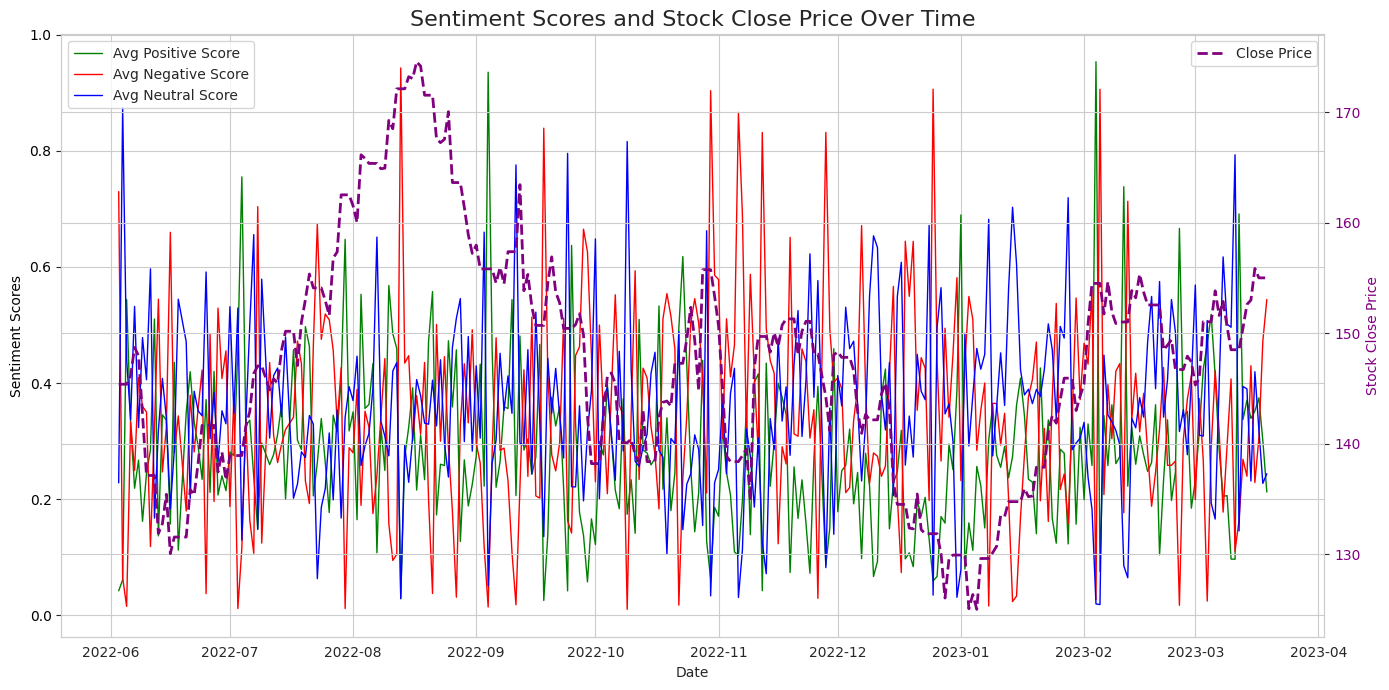

Sentiment scores and stock close price trends plotted successfully.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better aesthetics
sns.set_style("whitegrid")

# Create a figure and primary axes
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot sentiment scores on the primary y-axis
ax1.plot(df.index, df['avg_positive_score'], label='Avg Positive Score', color='green', linewidth=1)
ax1.plot(df.index, df['avg_negative_score'], label='Avg Negative Score', color='red', linewidth=1)
ax1.plot(df.index, df['avg_neutral_score'], label='Avg Neutral Score', color='blue', linewidth=1)

ax1.set_xlabel('Date')
ax1.set_ylabel('Sentiment Scores', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.legend(loc='upper left')

# Create a secondary y-axis for the 'close' price
ax2 = ax1.twinx()
ax2.plot(df.index, df['close'], label='Close Price', color='purple', linestyle='--', linewidth=2)
ax2.set_ylabel('Stock Close Price', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.legend(loc='upper right')

# Add title to the plot
plt.title('Sentiment Scores and Stock Close Price Over Time', fontsize=16)

# Improve layout and display plot
fig.tight_layout()
plt.show()
print("Sentiment scores and stock close price trends plotted successfully.")

In [5]:
selected_columns = ['avg_positive_score', 'avg_negative_score', 'avg_neutral_score', 'close']
correlation_matrix = df[selected_columns].corr()

print("Correlation Matrix between Sentiment Scores and Close Price:")
print(correlation_matrix)

Correlation Matrix between Sentiment Scores and Close Price:
                    avg_positive_score  avg_negative_score  avg_neutral_score  \
avg_positive_score            1.000000           -0.575383          -0.281884   
avg_negative_score           -0.575383            1.000000          -0.622526   
avg_neutral_score            -0.281884           -0.622526           1.000000   
close                         0.222878           -0.094509          -0.102396   

                       close  
avg_positive_score  0.222878  
avg_negative_score -0.094509  
avg_neutral_score  -0.102396  
close               1.000000  


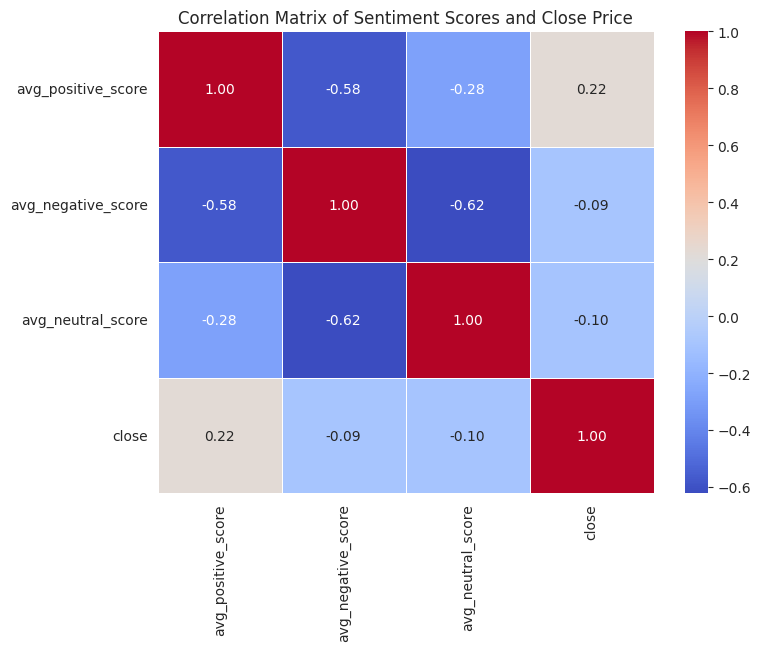

Heatmap of the correlation matrix displayed successfully.


In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Sentiment Scores and Close Price')
plt.show()
print("Heatmap of the correlation matrix displayed successfully.")

### Summary of Correlation Analysis

**Key Observations from the Correlation Matrix and Heatmap:**

*   **Positive Sentiment and Close Price:** `avg_positive_score` shows a positive correlation of `0.22` with the `close` price. This suggests a weak positive relationship, meaning that higher positive sentiment might be slightly associated with higher stock prices.

*   **Negative Sentiment and Close Price:** `avg_negative_score` has a negative correlation of `-0.09` with the `close` price. This indicates a very weak negative relationship, implying that higher negative sentiment has a negligible impact on stock prices.

*   **Neutral Sentiment and Close Price:** `avg_neutral_score` also shows a weak negative correlation of `-0.10` with the `close` price. Similar to negative sentiment, neutral sentiment appears to have a very slight inverse relationship with stock price.

*   **Inter-Sentiment Correlations:**
    *   `avg_positive_score` and `avg_negative_score` have a strong negative correlation of `-0.58`, which is expected as these are opposing sentiments.
    *   `avg_neutral_score` is negatively correlated with both `avg_positive_score` (`-0.28`) and `avg_negative_score` (`-0.62`). The stronger negative correlation with negative sentiment suggests that as negative sentiment decreases, neutral sentiment tends to increase more significantly, and vice versa.

**Overall Insights:**
The correlations between sentiment scores and the 'close' price are relatively weak. While positive sentiment has a slight positive correlation, and negative/neutral sentiments have very slight negative correlations, none of these relationships are particularly strong. This suggests that while sentiment might play a role, it is likely not the sole or primary driver of stock price movements in this dataset, and other factors would need to be considered for a comprehensive analysis.

## Summary:

### Data Analysis Key Findings

*   **Correlation with Close Price**:
    *   `avg_positive_score` showed a weak positive correlation of 0.22 with the `close` price, suggesting a slight association between higher positive sentiment and higher stock prices.
    *   `avg_negative_score` exhibited a very weak negative correlation of -0.09 with the `close` price, indicating a negligible inverse relationship.
    *   `avg_neutral_score` displayed a weak negative correlation of -0.10 with the `close` price, similar to negative sentiment, suggesting a very slight inverse relationship.
*   **Inter-Sentiment Correlations**:
    *   `avg_positive_score` and `avg_negative_score` had a strong negative correlation of -0.58, which is expected given their opposing nature.
    *   `avg_neutral_score` was negatively correlated with `avg_positive_score` (-0.28) and more strongly with `avg_negative_score` (-0.62). This implies that as negative sentiment decreases, neutral sentiment tends to increase more significantly.

### Insights or Next Steps

*   The correlations between sentiment scores and the 'close' price are relatively weak, suggesting that sentiment alone is not a primary driver of stock price movements in this dataset.
*   Further analysis should consider integrating other market factors, economic indicators, or company-specific news to develop a more comprehensive model for predicting stock price fluctuations.


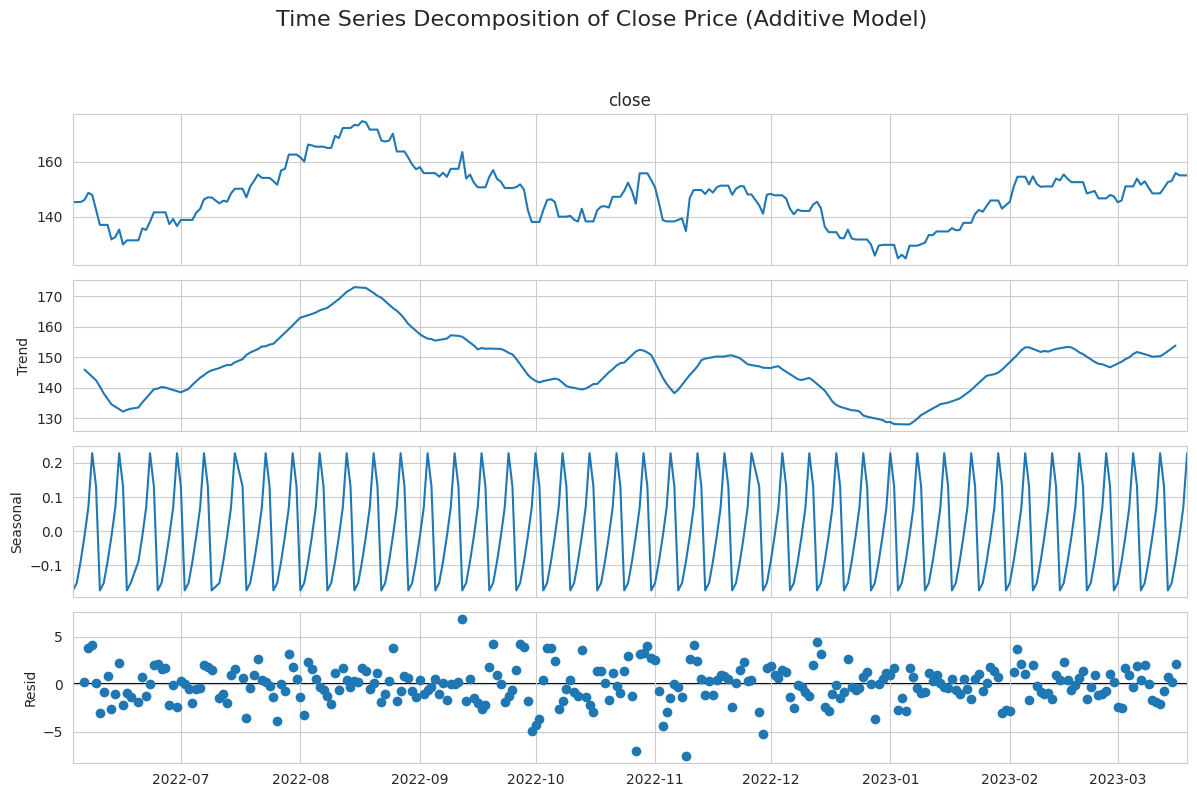

Time series decomposition of 'close' price completed and plotted successfully.


In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Perform additive time series decomposition on the 'close' price
decomposition_result = seasonal_decompose(df['close'], model='additive', period=7) # Assuming a weekly seasonality (7 days)

# Plot the decomposition components
fig = decomposition_result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition of Close Price (Additive Model)', y=1.02, fontsize=16) # Add a main title
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

print("Time series decomposition of 'close' price completed and plotted successfully.")